<a href="https://www.kaggle.com/code/lalit7881/ai-impact-on-jobs-2030-eda-100?scriptVersionId=321372885" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dreamtensor/ai-impact-on-jobs-2030/AI_Impact_on_Jobs_2030.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/dreamtensor/ai-impact-on-jobs-2030/AI_Impact_on_Jobs_2030.csv")

In [3]:
df.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [4]:
df.tail()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
2995,Doctor,111319,6,Bachelor's,0.24,1.18,0.20,Low,0.73,0.37,0.99,0.07,0.08,0.92,0.65,0.33,0.76,0.45
2996,UX Researcher,44363,29,PhD,0.65,0.74,0.35,Medium,0.23,0.48,0.05,0.88,0.56,0.29,0.69,0.80,0.61,0.20
2997,Data Scientist,61325,23,Master's,0.64,0.94,0.39,Medium,0.28,0.62,0.73,0.21,0.96,0.01,0.70,0.29,0.48,0.57
2998,Graphic Designer,110296,7,PhD,0.95,1.23,0.46,Medium,0.21,0.18,0.14,0.22,0.55,0.68,0.31,0.55,0.34,0.70
2999,Graphic Designer,123909,25,PhD,0.69,0.56,0.49,Medium,0.77,0.54,0.95,0.05,0.29,0.22,0.77,0.52,0.14,0.29


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

In [6]:
df.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Job_Title                       object
Average_Salary                   int64
Years_Experience                 int64
Education_Level                 object
AI_Exposure_Index              float64
Tech_Growth_Factor             float64
Automation_Probability_2030    float64
Risk_Category                   object
Skill_1                        float64
Skill_2                        float64
Skill_3                        float64
Skill_4                        float64
Skill_5                        float64
Skill_6                        float64
Skill_7                        float64
Skill_8                        float64
Skill_9                        float64
Skill_10                       float64
dtype: object

In [11]:
df.shape

(3000, 18)

In [12]:
df.columns

Index(['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level',
       'AI_Exposure_Index', 'Tech_Growth_Factor',
       'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2',
       'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8',
       'Skill_9', 'Skill_10'],
      dtype='object')

In [13]:
df.nunique()

Job_Title                        20
Average_Salary                 2960
Years_Experience                 30
Education_Level                   4
AI_Exposure_Index               101
Tech_Growth_Factor              101
Automation_Probability_2030      91
Risk_Category                     3
Skill_1                         101
Skill_2                         101
Skill_3                         101
Skill_4                         101
Skill_5                         101
Skill_6                         101
Skill_7                         101
Skill_8                         101
Skill_9                         101
Skill_10                        101
dtype: int64

## EDA

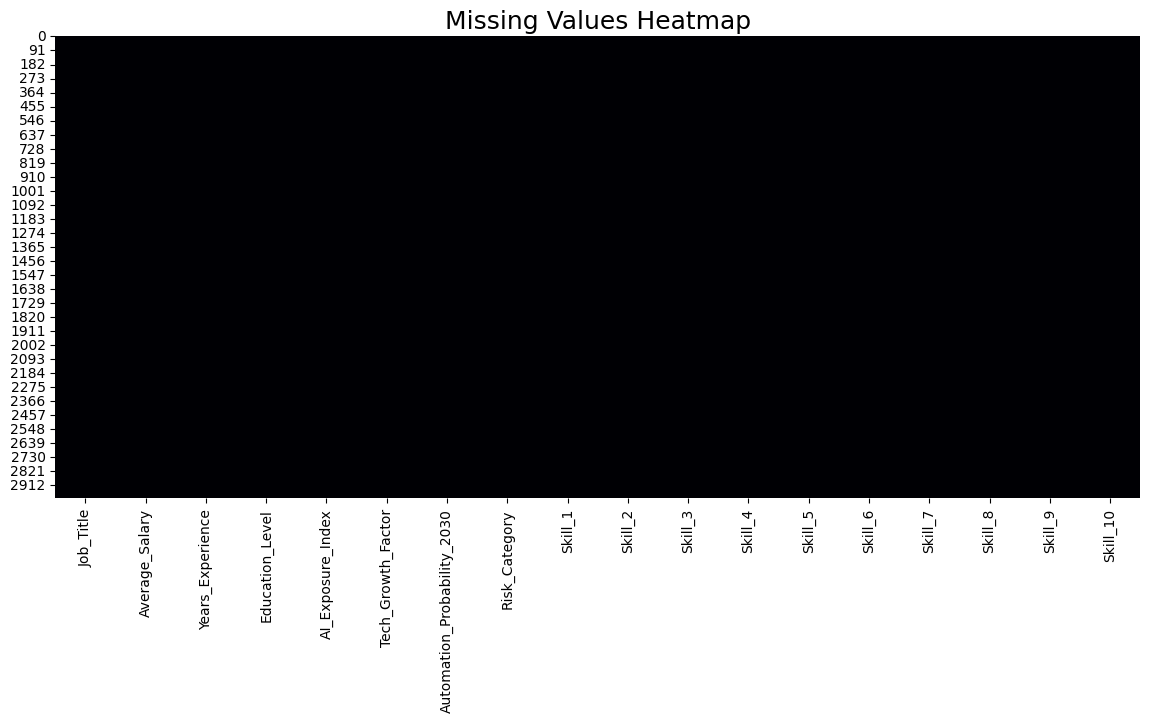

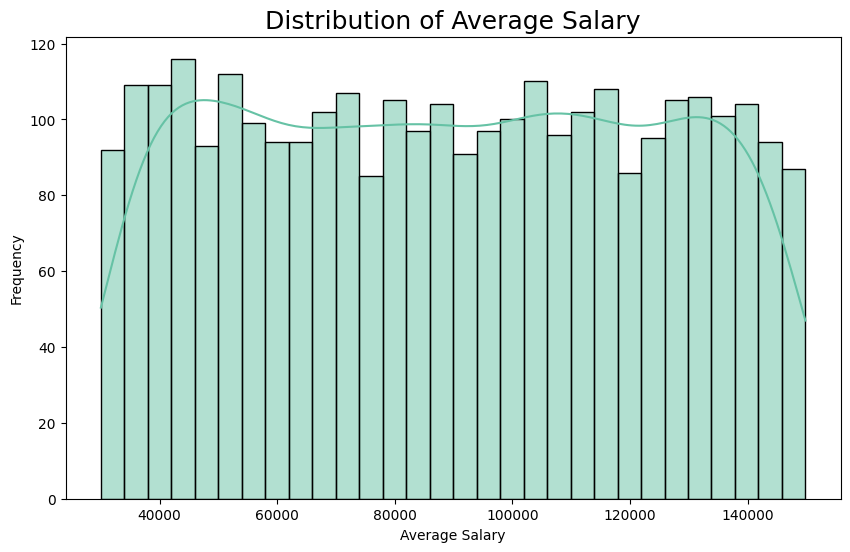

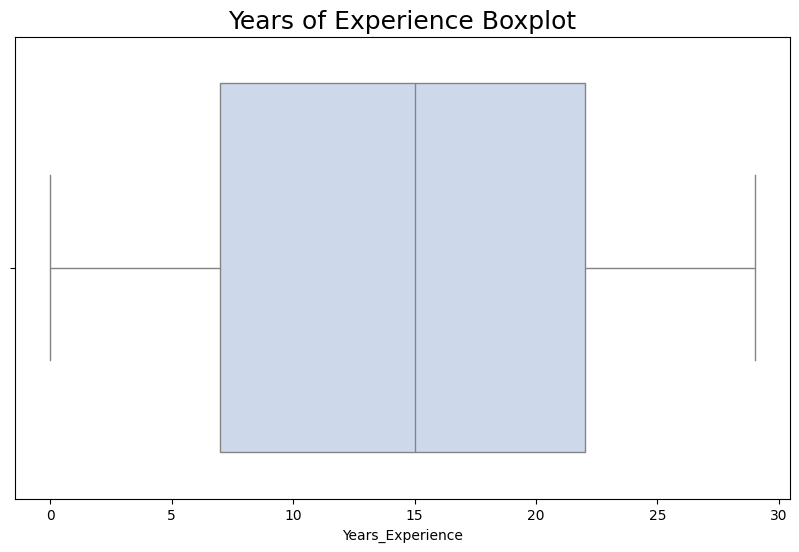

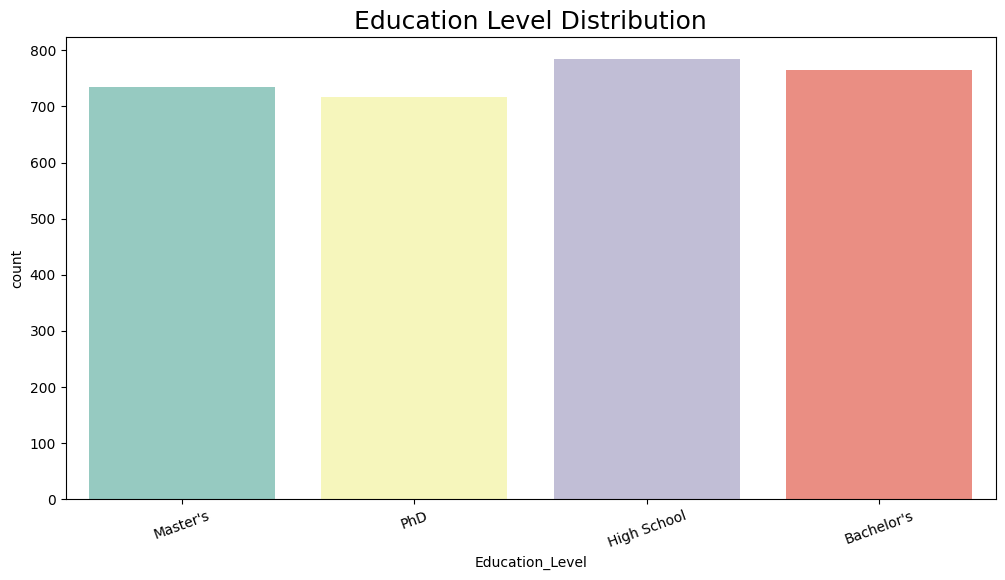

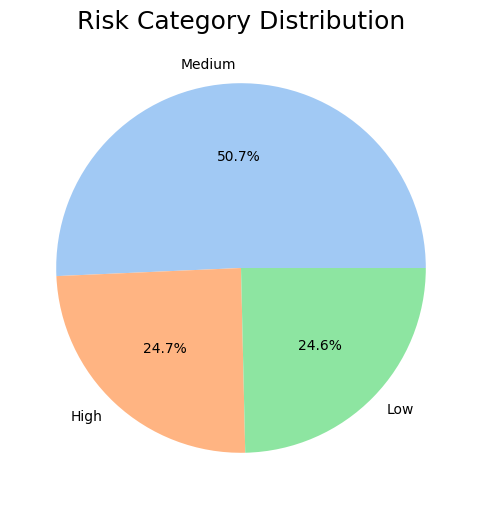

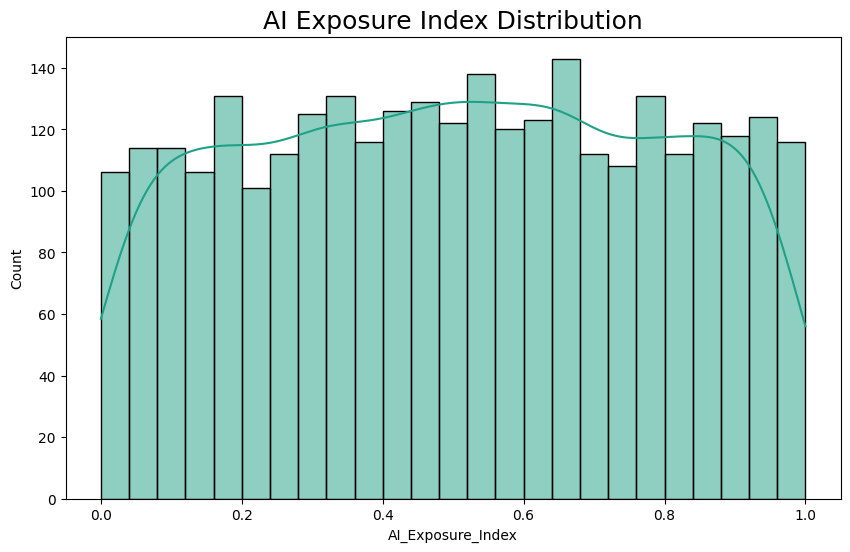

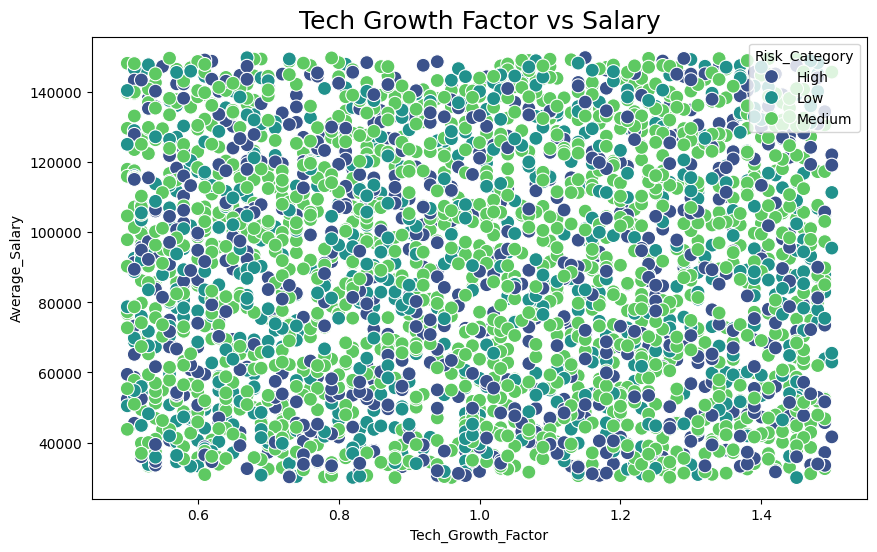

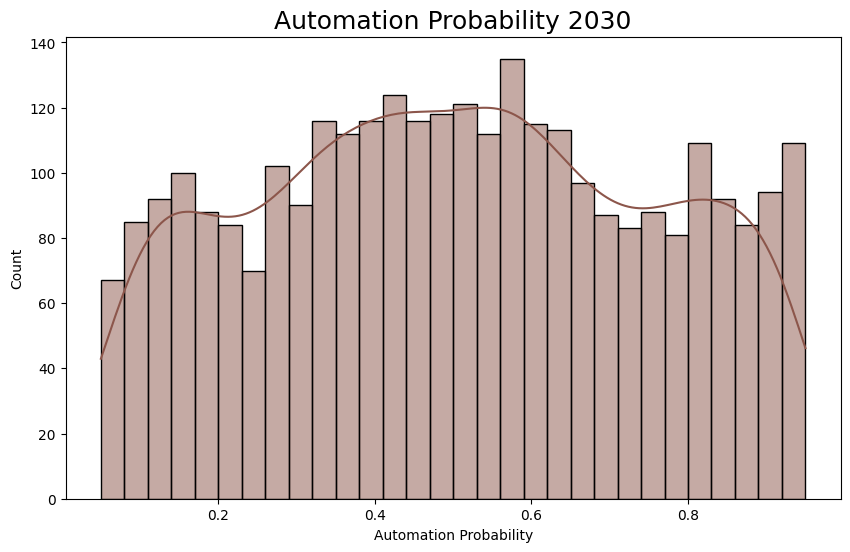

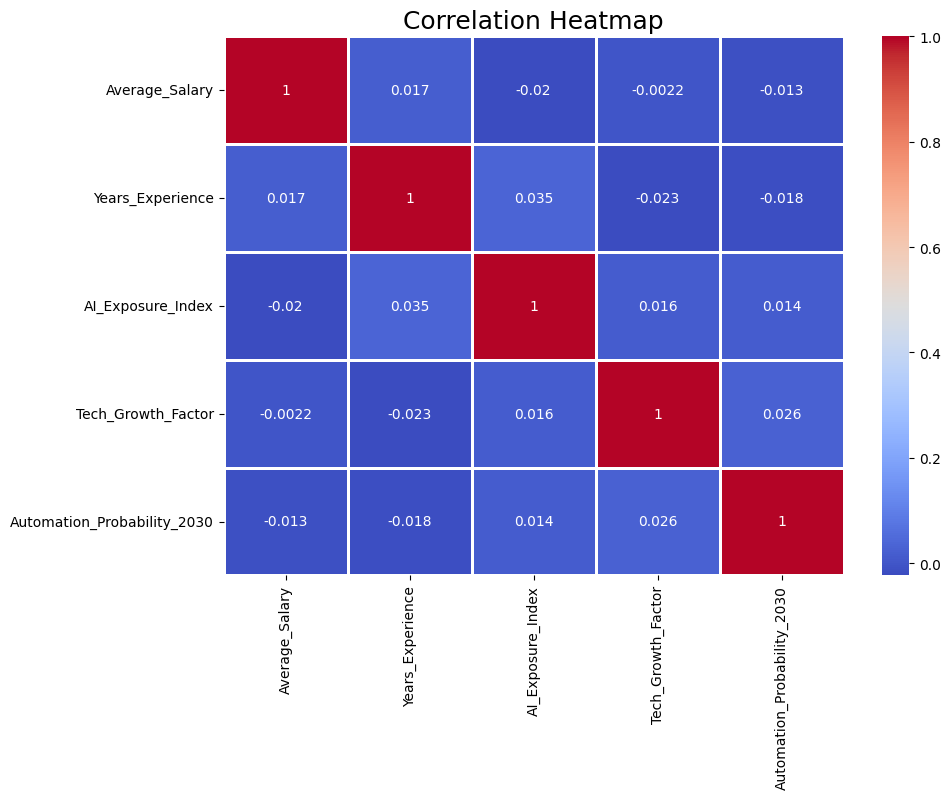

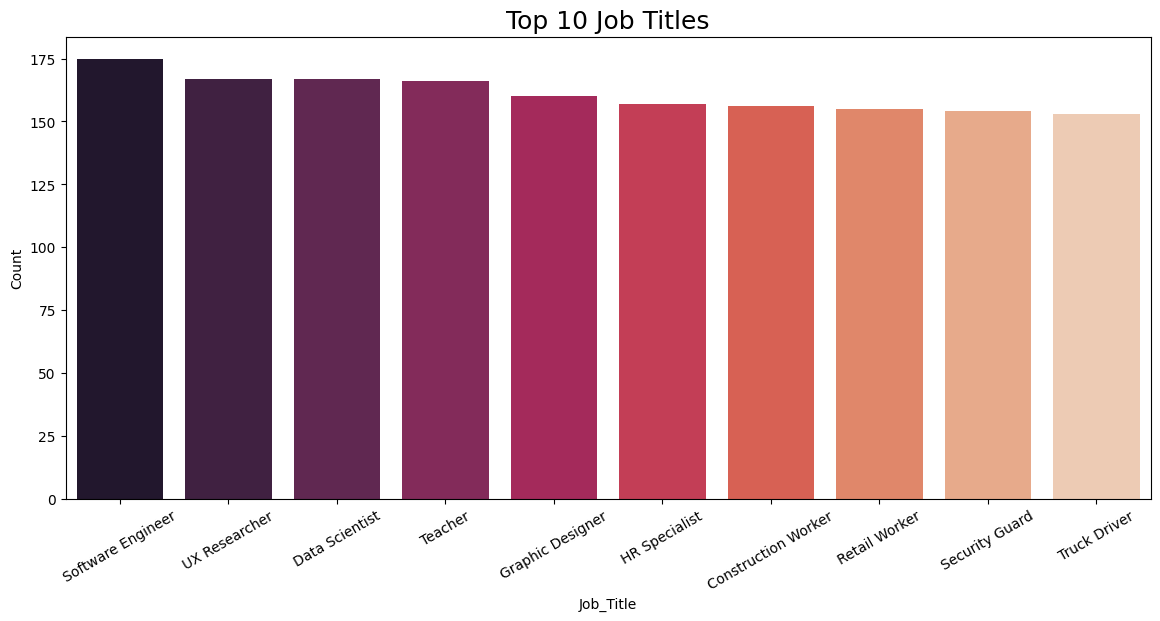

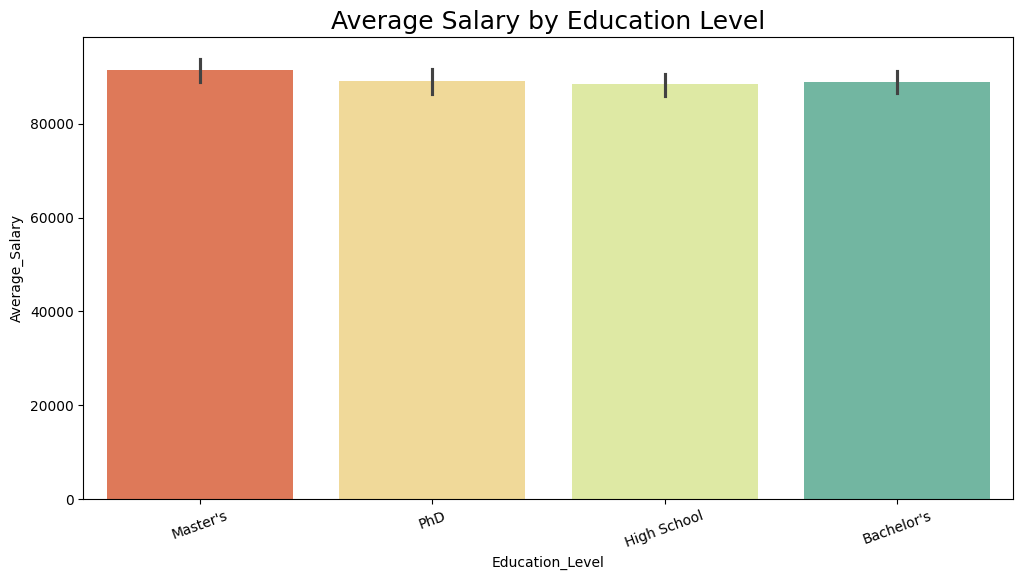

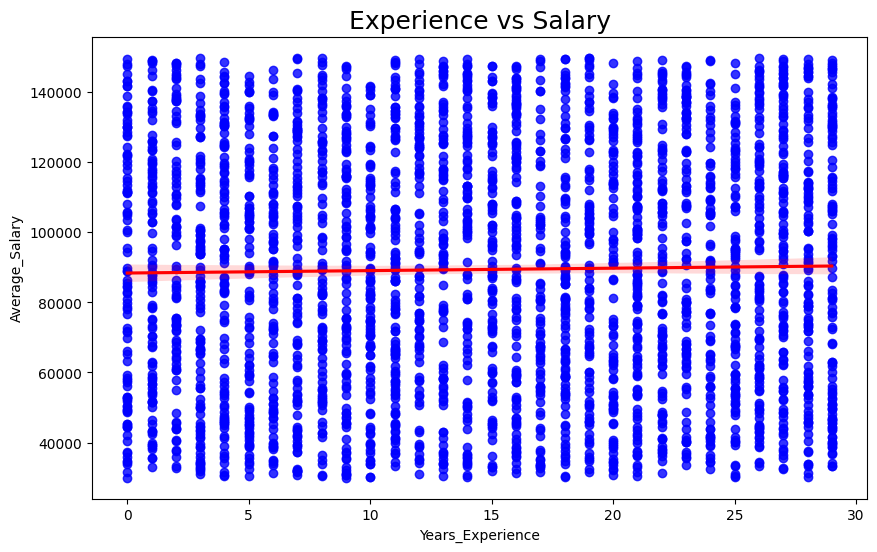

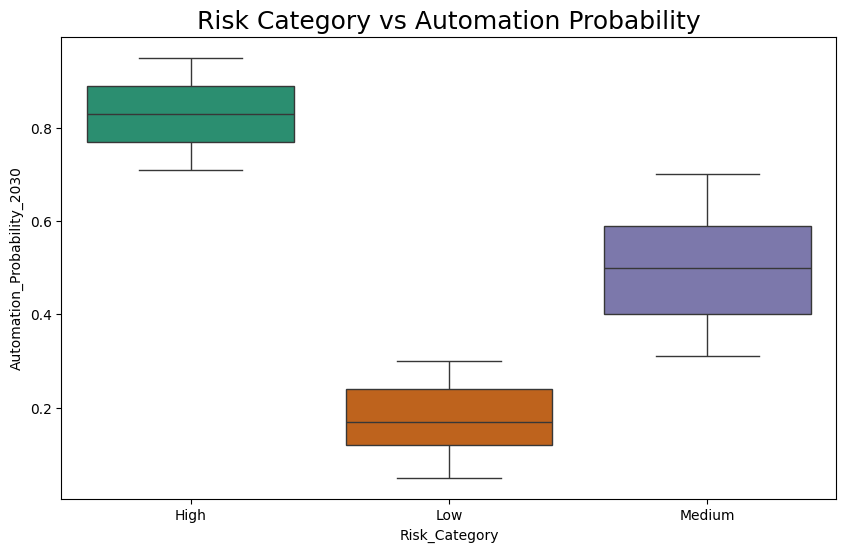

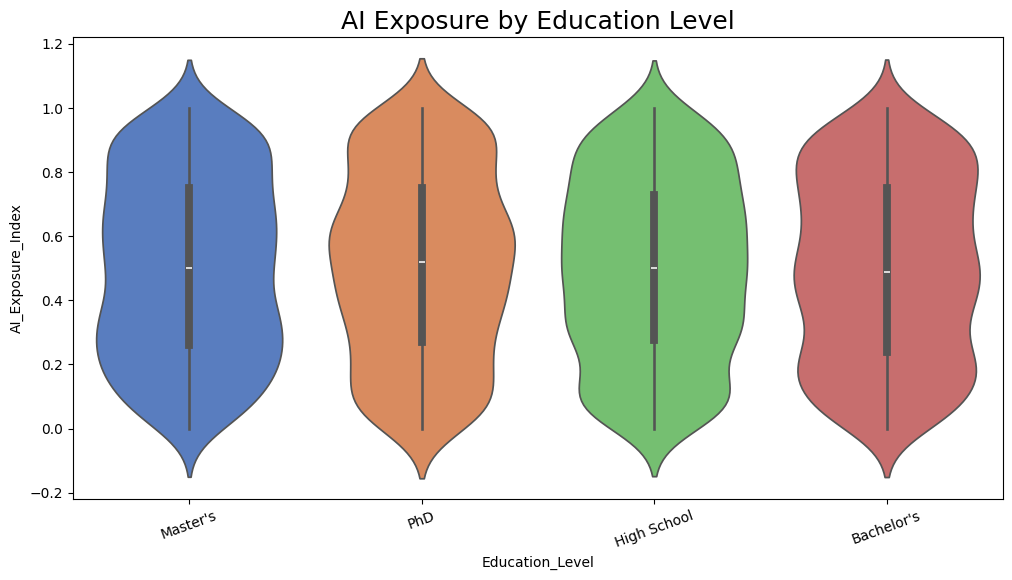

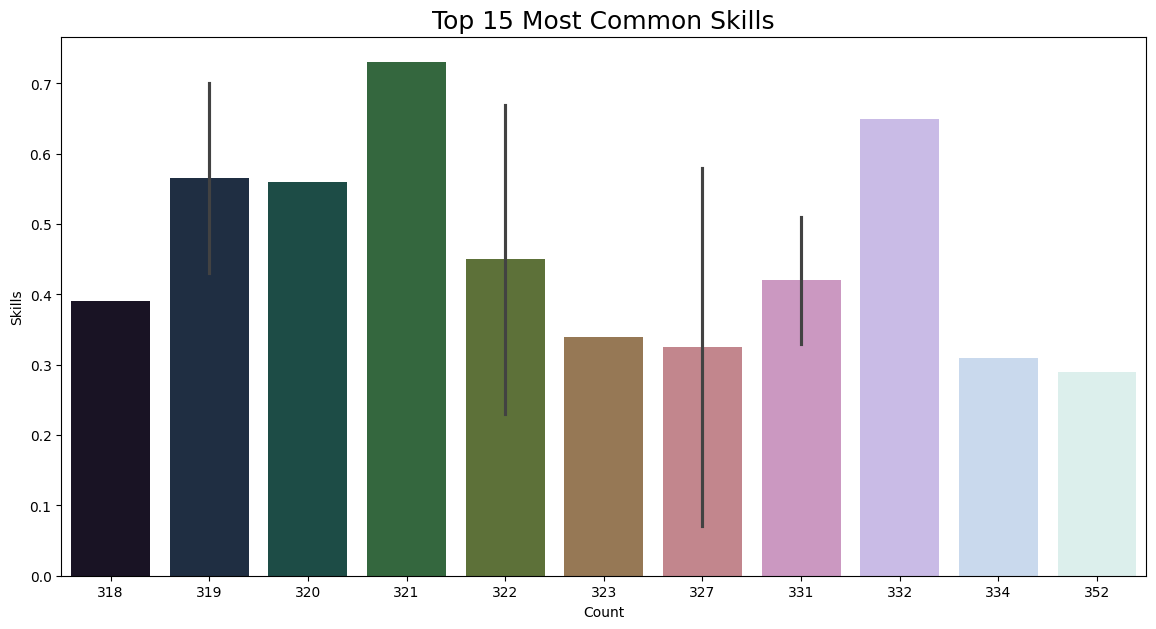

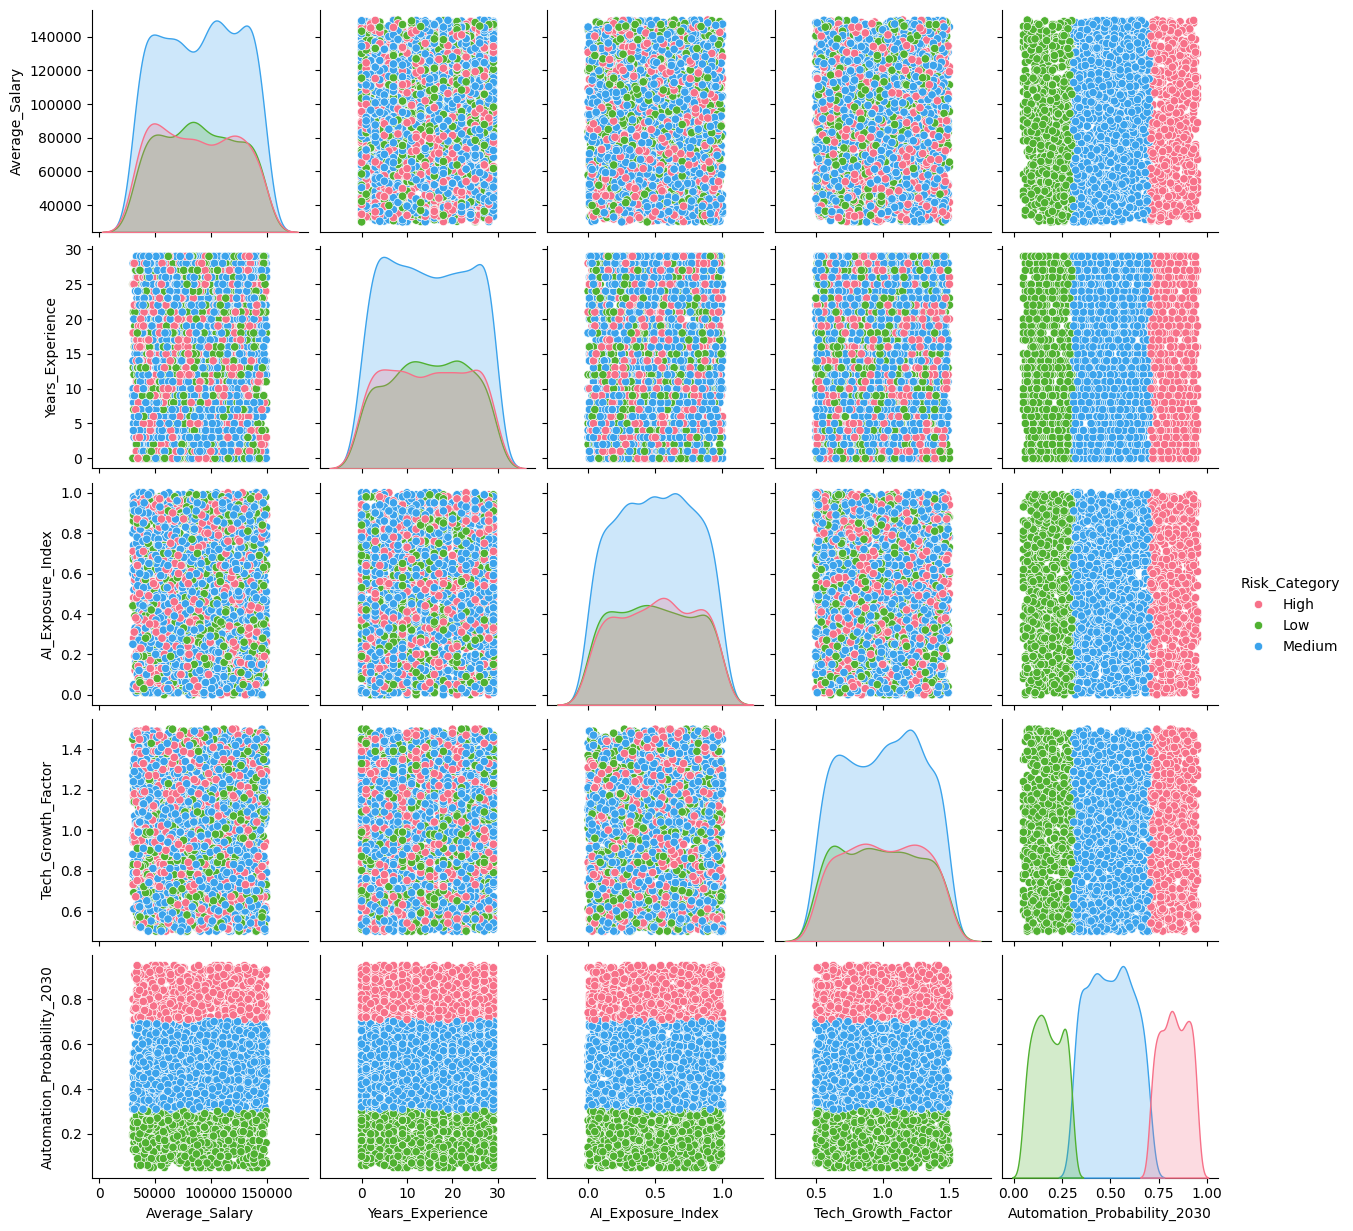

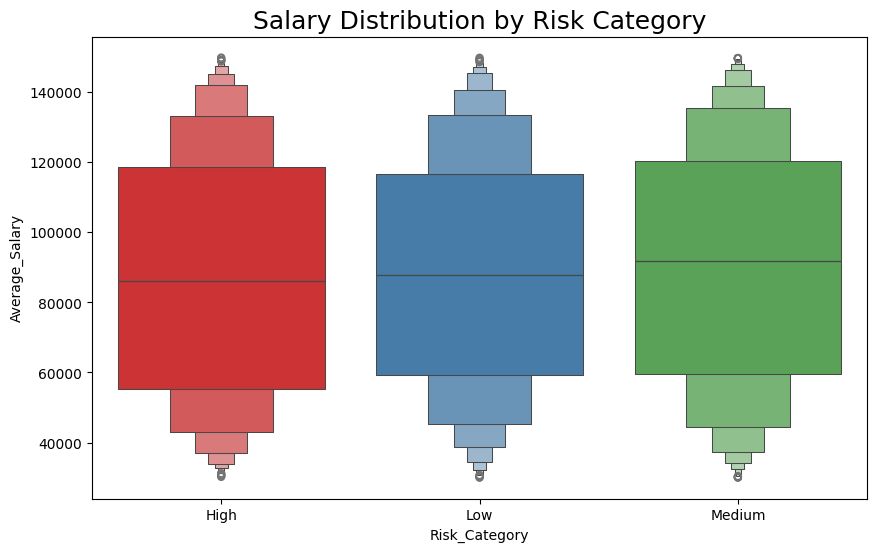

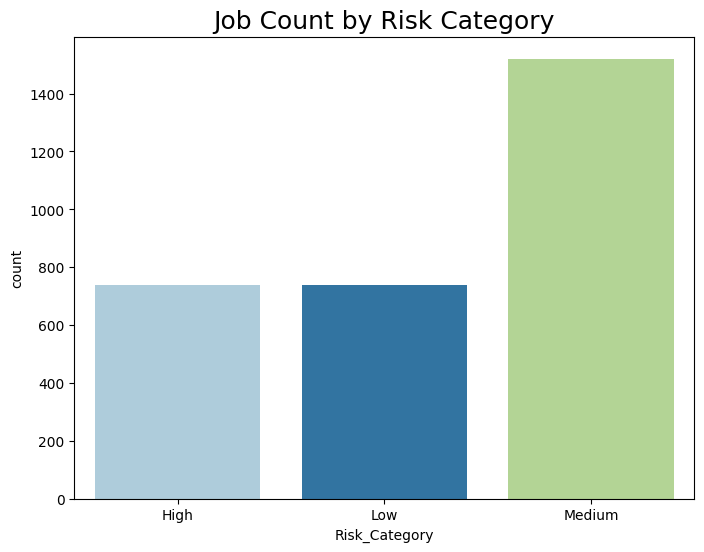

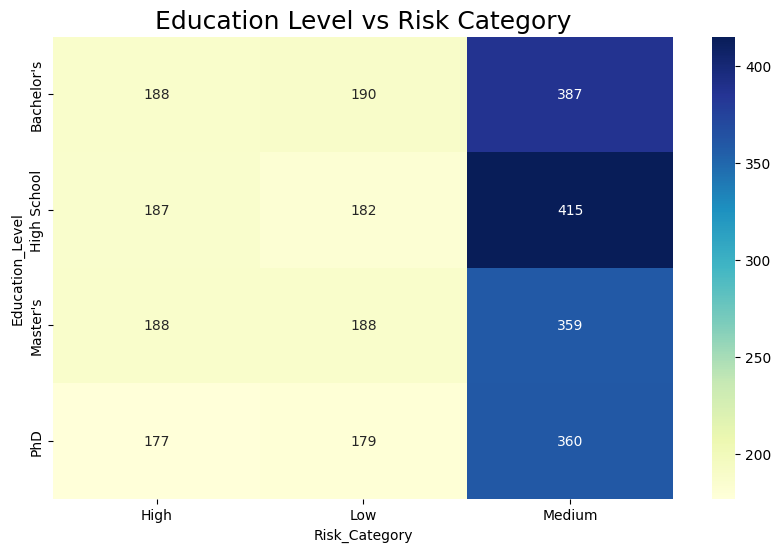


Visualization Completed Successfully!


In [14]:
# Different Color Palettes
colors1 = sns.color_palette("Set2")
colors2 = sns.color_palette("coolwarm")
colors3 = sns.color_palette("viridis")
colors4 = sns.color_palette("tab10")
colors5 = sns.color_palette("husl")

# ============================================
# 1. MISSING VALUES HEATMAP
# ============================================

plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap="magma")
plt.title("Missing Values Heatmap", fontsize=18)
plt.show()

# ============================================
# 2. DISTRIBUTION OF AVERAGE SALARY
# ============================================

plt.figure(figsize=(10,6))
sns.histplot(
    df["Average_Salary"],
    bins=30,
    kde=True,
    color=colors1[0]
)
plt.title("Distribution of Average Salary", fontsize=18)
plt.xlabel("Average Salary")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 3. YEARS OF EXPERIENCE DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))
sns.boxplot(
    x=df["Years_Experience"],
    color=colors2[2]
)
plt.title("Years of Experience Boxplot", fontsize=18)
plt.show()

# ============================================
# 4. EDUCATION LEVEL COUNT
# ============================================

plt.figure(figsize=(12,6))
sns.countplot(
    x="Education_Level",
    data=df,
    palette="Set3"
)

plt.title("Education Level Distribution", fontsize=18)
plt.xticks(rotation=20)
plt.show()

# ============================================
# 5. RISK CATEGORY DISTRIBUTION
# ============================================

plt.figure(figsize=(8,6))

risk_counts = df["Risk_Category"].value_counts()

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)

plt.title("Risk Category Distribution", fontsize=18)
plt.show()

# ============================================
# 6. AI EXPOSURE INDEX DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["AI_Exposure_Index"],
    bins=25,
    kde=True,
    color=colors3[3]
)

plt.title("AI Exposure Index Distribution", fontsize=18)
plt.show()

# ============================================
# 7. TECH GROWTH FACTOR VS SALARY
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Tech_Growth_Factor",
    y="Average_Salary",
    hue="Risk_Category",
    palette="viridis",
    data=df,
    s=100
)

plt.title("Tech Growth Factor vs Salary", fontsize=18)
plt.show()

# ============================================
# 8. AUTOMATION PROBABILITY DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Automation_Probability_2030"],
    bins=30,
    kde=True,
    color=colors4[5]
)

plt.title("Automation Probability 2030", fontsize=18)
plt.xlabel("Automation Probability")
plt.show()

# ============================================
# 9. CORRELATION HEATMAP
# ============================================

numeric_cols = [
    "Average_Salary",
    "Years_Experience",
    "AI_Exposure_Index",
    "Tech_Growth_Factor",
    "Automation_Probability_2030"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# ============================================
# 10. TOP JOB TITLES
# ============================================

top_jobs = df["Job_Title"].value_counts().head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_jobs.index,
    y=top_jobs.values,
    palette="rocket"
)

plt.title("Top 10 Job Titles", fontsize=18)
plt.xticks(rotation=30)
plt.ylabel("Count")
plt.show()

# ============================================
# 11. AVG SALARY BY EDUCATION LEVEL
# ============================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Education_Level",
    y="Average_Salary",
    data=df,
    palette="Spectral"
)

plt.title("Average Salary by Education Level", fontsize=18)
plt.xticks(rotation=20)
plt.show()

# ============================================
# 12. EXPERIENCE VS SALARY
# ============================================

plt.figure(figsize=(10,6))

sns.regplot(
    x="Years_Experience",
    y="Average_Salary",
    data=df,
    scatter_kws={"color":"blue"},
    line_kws={"color":"red"}
)

plt.title("Experience vs Salary", fontsize=18)
plt.show()

# ============================================
# 13. RISK CATEGORY VS AUTOMATION
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Risk_Category",
    y="Automation_Probability_2030",
    data=df,
    palette="Dark2"
)

plt.title("Risk Category vs Automation Probability", fontsize=18)
plt.show()

# ============================================
# 14. AI EXPOSURE BY EDUCATION LEVEL
# ============================================

plt.figure(figsize=(12,6))

sns.violinplot(
    x="Education_Level",
    y="AI_Exposure_Index",
    data=df,
    palette="muted"
)

plt.title("AI Exposure by Education Level", fontsize=18)
plt.xticks(rotation=20)
plt.show()

# ============================================
# 15. SKILL ANALYSIS
# ============================================

skill_columns = [
    'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5',
    'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10'
]

# Combine all skills
all_skills = pd.Series(
    df[skill_columns].values.ravel()
)

top_skills = all_skills.value_counts().head(15)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index,
    palette="cubehelix"
)

plt.title("Top 15 Most Common Skills", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Skills")
plt.show()

# ============================================
# 16. PAIRPLOT
# ============================================

pairplot_cols = [
    "Average_Salary",
    "Years_Experience",
    "AI_Exposure_Index",
    "Tech_Growth_Factor",
    "Automation_Probability_2030",
    "Risk_Category"
]

sns.pairplot(
    df[pairplot_cols],
    hue="Risk_Category",
    palette="husl"
)

plt.show()

# ============================================
# 17. SALARY BY RISK CATEGORY
# ============================================

plt.figure(figsize=(10,6))

sns.boxenplot(
    x="Risk_Category",
    y="Average_Salary",
    data=df,
    palette="Set1"
)

plt.title("Salary Distribution by Risk Category", fontsize=18)
plt.show()

# ============================================
# 18. COUNT OF JOBS BY RISK CATEGORY
# ============================================

plt.figure(figsize=(8,6))

sns.countplot(
    x="Risk_Category",
    data=df,
    palette="Paired"
)

plt.title("Job Count by Risk Category", fontsize=18)
plt.show()

# ============================================
# 19. HEATMAP OF EDUCATION VS RISK
# ============================================

cross_tab = pd.crosstab(
    df["Education_Level"],
    df["Risk_Category"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cross_tab,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Education Level vs Risk Category", fontsize=18)
plt.show()

# ============================================
# 20. FINAL SUMMARY
# ============================================

print("\nVisualization Completed Successfully!")

## Feature Engineering


Target Classes:
{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Training Shape: (2400, 17)
Testing Shape: (600, 17)

Categorical Columns:
['Job_Title', 'Education_Level']

Numeric Columns:
['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Automation_Probability_2030', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10']


MODEL: Logistic Regression

Accuracy: 0.9933

Classification Report:

              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



<Figure size 1200x800 with 0 Axes>

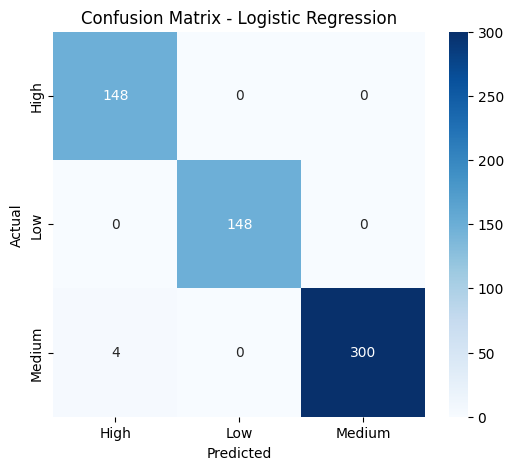



MODEL: Decision Tree

Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      1.00      1.00       304

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



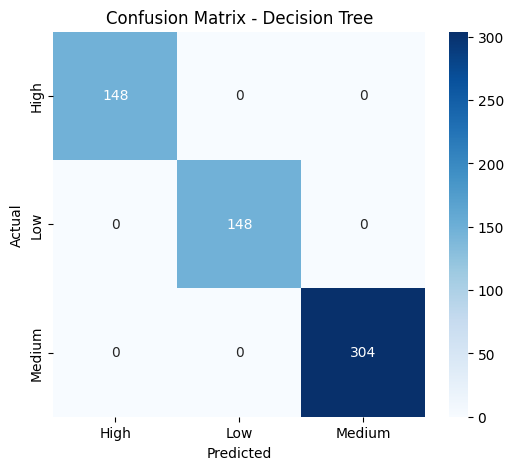



MODEL: Random Forest

Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      1.00      1.00       304

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



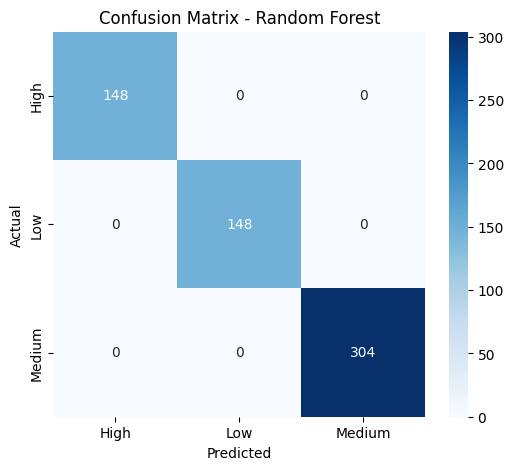



MODEL: Gradient Boosting

Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      1.00      1.00       304

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



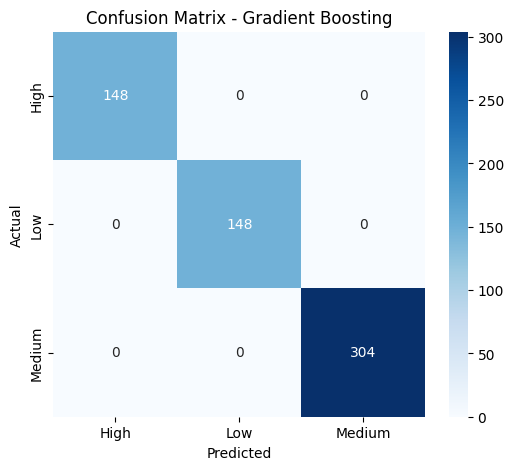



MODEL: KNN

Accuracy: 0.8167

Classification Report:

              precision    recall  f1-score   support

        High       0.83      0.76      0.80       148
         Low       0.88      0.76      0.81       148
      Medium       0.79      0.87      0.83       304

    accuracy                           0.82       600
   macro avg       0.83      0.80      0.81       600
weighted avg       0.82      0.82      0.82       600



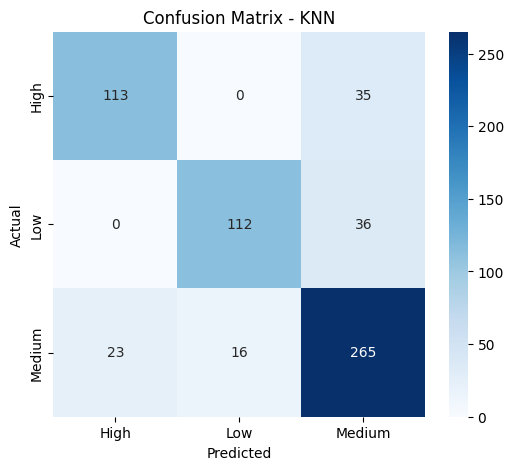



MODEL: SVM

Accuracy: 0.9933

Classification Report:

              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



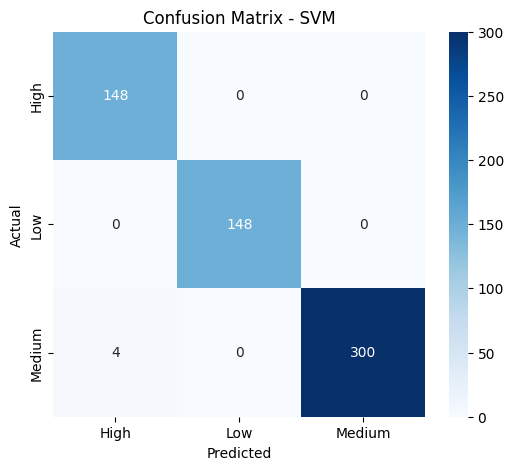



FINAL MODEL COMPARISON
                 Model  Accuracy
1        Decision Tree  1.000000
2        Random Forest  1.000000
3    Gradient Boosting  1.000000
0  Logistic Regression  0.993333
5                  SVM  0.993333
4                  KNN  0.816667


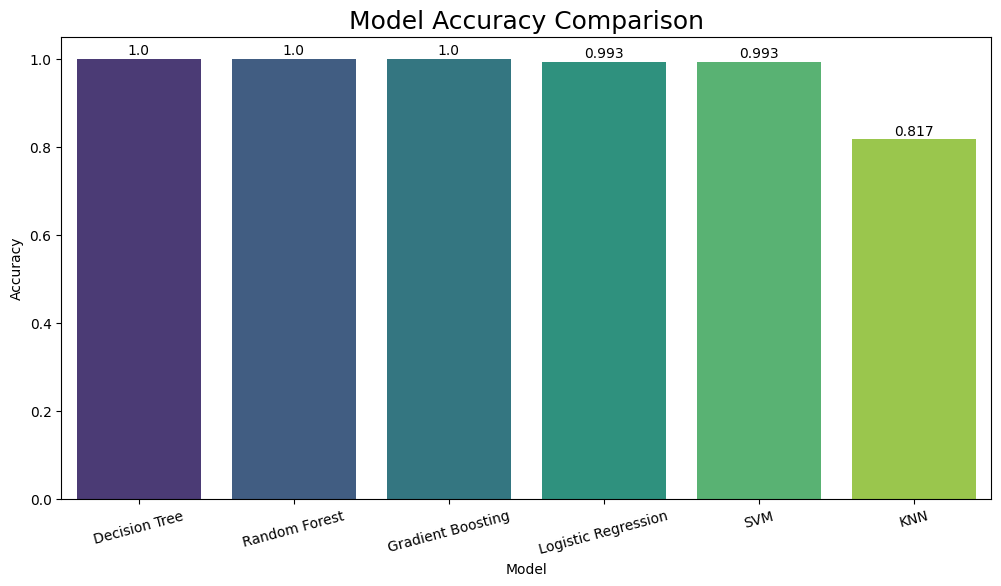


Best Performing Model:
Model       Decision Tree
Accuracy              1.0
Name: 1, dtype: object


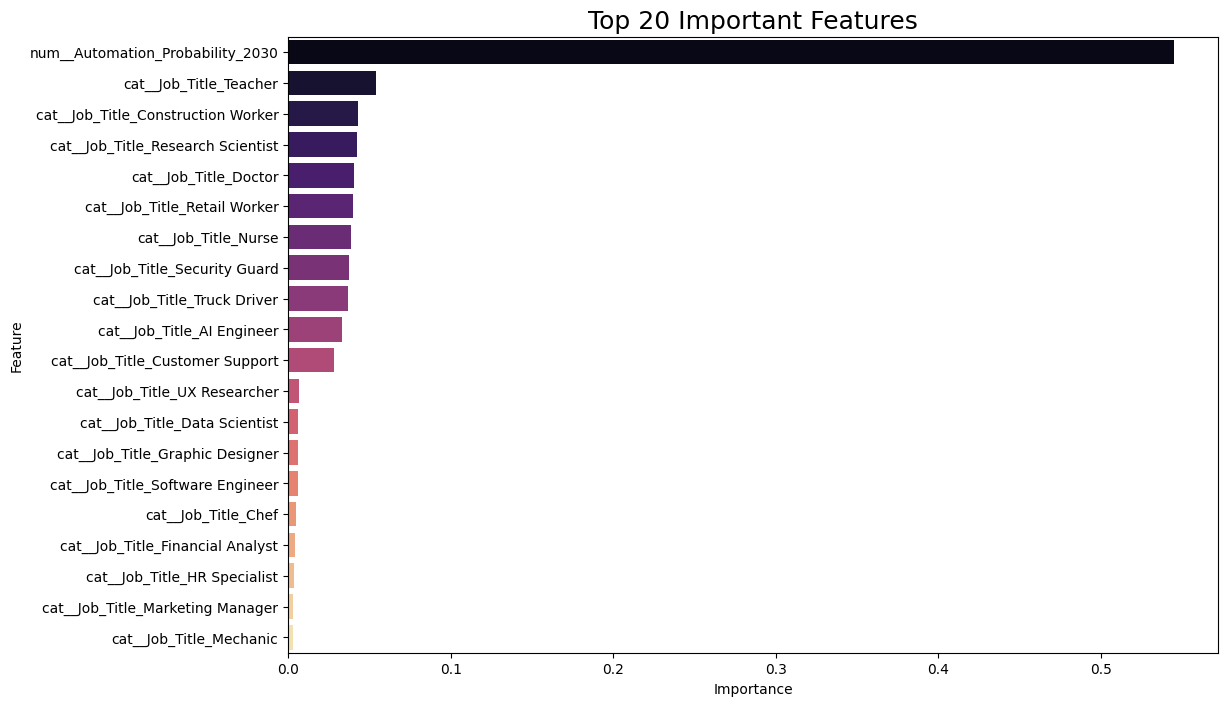


Machine Learning Pipeline Completed Successfully!


In [15]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)




target = "Risk_Category"

# =========================================================
# LABEL ENCODING TARGET ONLY
# =========================================================
# IMPORTANT:
# Encode ONLY target using LabelEncoder
# Features handled using OneHotEncoder inside pipeline
# Prevents Data Leakage

le = LabelEncoder()

df[target] = le.fit_transform(df[target])

print("\nTarget Classes:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# =========================================================
# FEATURES AND TARGET
# =========================================================

X = df.drop(columns=[target])
y = df[target]

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# Split BEFORE preprocessing to avoid leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =========================================================
# IDENTIFY COLUMN TYPES
# =========================================================

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

# =========================================================
# PREPROCESSING PIPELINES
# =========================================================

# Numeric Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine Pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# =========================================================
# STORE RESULTS
# =========================================================

results = []

# =========================================================
# ROC CURVE PLOT
# =========================================================

plt.figure(figsize=(12,8))

# =========================================================
# TRAIN EACH MODEL
# =========================================================

for name, model in models.items():

    print("\n")
    print("="*60)
    print(f"MODEL: {name}")
    print("="*60)

    # Full Pipeline
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    pipeline.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================

    y_pred = pipeline.predict(X_test)

    # =====================================================
    # ACCURACY
    # =====================================================

    acc = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy: {acc:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=le.classes_
        )
    )

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # =====================================================
    # ROC AUC SCORE
    # =====================================================

    # Binary Classification Only
    if len(np.unique(y)) == 2:

        y_prob = pipeline.predict_proba(X_test)[:,1]

        roc_auc = roc_auc_score(y_test, y_prob)

        print(f"ROC-AUC Score: {roc_auc:.4f}")

        # ROC Curve
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={roc_auc:.3f})"
        )

    # Save Results
    results.append({
        "Model": name,
        "Accuracy": acc
    })

# =========================================================
# FINAL ROC CURVE
# =========================================================

if len(np.unique(y)) == 2:

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.show()

# =========================================================
# RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(results)

# =========================================================
# SORT RESULTS
# =========================================================

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(results_df)

# =========================================================
# BARPLOT OF MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df,
    palette="viridis"
)

plt.title("Model Accuracy Comparison", fontsize=18)
plt.xticks(rotation=15)

for index, row in results_df.iterrows():

    plt.text(
        x=list(results_df.index).index(index),
        y=row["Accuracy"] + 0.01,
        s=round(row["Accuracy"], 3),
        ha='center'
    )

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model = results_df.iloc[0]

print("\nBest Performing Model:")
print(best_model)

# =========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# =========================================================

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

# Get Encoded Feature Names
encoded_features = rf_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

# Feature Importance
importance = rf_pipeline.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 20 Features
top_features = feature_importance_df.head(20)

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(12,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features,
    palette="magma"
)

plt.title("Top 20 Important Features", fontsize=18)
plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================

results_df.to_csv(
    "model_results.csv",
    index=False
)

print("\nMachine Learning Pipeline Completed Successfully!")

## Thank you...pls upvote!!!!!!!!!!!